In [1]:
import numpy as np 
import pandas as pd

traffic_meta = pd.read_csv('/home/mala711/GEODE2025/data/traffic_metadata.csv')
traffic_data = pd.read_csv('/home/mala711/GEODE2025/data/traffic_data.csv', index_col=0)
traffic_adj_file = np.load('/home/mala711/GEODE2025/data/traffic_adj.npz')
tr_edge_index = traffic_adj_file['edge_index']
tr_edge_weight = traffic_adj_file['edge_weight']

traffic_adj = np.eye(len(traffic_data.columns), dtype=np.float32)
traffic_adj[tuple(tr_edge_index)] = tr_edge_weight

In [2]:
air_meta = pd.read_csv('/home/mala711/GEODE2025/data/air_metadata.csv')
air_data = pd.read_csv('/home/mala711/GEODE2025/data/air_data.csv', index_col=0)
air_adj_file = np.load('/home/mala711/GEODE2025/data/air_adj.npz')
ar_edge_index = air_adj_file['edge_index']
ar_edge_weight = air_adj_file['edge_weight']

air_adj = np.eye(len(air_data.columns), dtype=np.float32)
air_adj[tuple(ar_edge_index)] = ar_edge_weight

In [3]:
full_data = pd.read_csv('/home/mala711/GEODE2025/data/full_data.csv', parse_dates=['Time'], index_col='Time')  
cross_dist = pd.read_csv('/home/mala711/GEODE2025/data/cross_dist.csv')   
cr_adj_file = np.load('/home/mala711/GEODE2025/data/cross_adj.npz')
cr_edge_index = cr_adj_file['edge_index']
cr_edge_weight = cr_adj_file['edge_weight']

crs_adj = np.zeros((len(air_data.columns), len(traffic_data.columns)))
crs_adj[tuple(cr_edge_index)] = cr_edge_weight
full_data

,Berkeley-Aquatic Park,Concord-2956-A Treat Blvd,Livermore-793 Rincon Avenue,Oakland-9925 International Blvd,Oakland-Laney College,Oakland-West,Pleasanton-Owens Ct,Redwood City,San Francisco-Arkansas Street,San Jose-Jackson Street,...,403337,403343,403346,403349,401596,401580,401356,401347,400958,403902
Time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,0.01490,0.01560,0.0241,0.01950,0.0146,0.02620,NaN,0.0186,0.03030,0.0283,...,56.0,44.0,29.0,38.0,55.0,293.0,36.0,59.0,0.0,50.0
2018-01-01 01:00:00,0.02110,0.01380,0.0220,0.01590,0.0162,0.02740,NaN,0.0165,0.02890,0.0258,...,136.0,105.0,123.0,114.0,122.0,317.0,78.0,120.0,105.0,160.0
2018-01-01 02:00:00,0.02095,0.01560,0.0207,0.01610,0.0253,0.02510,NaN,0.0152,0.02670,0.0229,...,93.0,74.0,83.0,76.0,84.0,291.0,75.0,90.0,43.0,131.0
2018-01-01 03:00:00,0.02080,0.01445,0.0197,0.01595,0.0236,0.02395,NaN,0.0136,0.02715,0.0200,...,64.0,62.0,55.0,43.0,58.0,263.0,45.0,85.0,0.0,89.0
2018-01-01 04:00:00,0.02130,0.01330,0.0187,0.01580,0.0219,0.02280,NaN,0.0120,0.02760,0.0171,...,33.0,31.0,34.0,35.0,46.0,186.0,24.0,44.0,0.0,48.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-31 19:00:00,0.01320,0.00160,0.0011,0.00270,0.0041,0.00840,0.0055,0.0037,0.00630,0.0016,...,280.0,234.0,235.0,156.0,228.0,428.0,333.0,268.0,253.0,163.0
2018-12-31 20:00:00,0.01470,0.00200,0.0011,0.00230,0.0074,0.00810,0.0035,0.0026,0.00710,0.0014,...,263.0,196.0,185.0,126.0,183.0,346.0,213.0,151.0,191.0,180.0
2018-12-31 21:00:00,0.01170,0.00200,0.0015,0.00300,0.0042,0.00690,0.0029,0.0028,0.00860,0.0012,...,143.0,148.0,127.0,99.0,166.0,268.0,163.0,121.0,150.0,142.0


In [4]:
traffic_data.shape

(8760, 326)

In [5]:
from scipy.stats import pearsonr

t_data = np.nan_to_num(traffic_data.to_numpy())
a_data = np.nan_to_num(air_data.to_numpy())

n1, n2 = a_data.shape[1], t_data.shape[1]
corr_matrix = np.zeros((n1, n2))

for i in range(n1):
    for j in range(n2):
        corr_matrix[i, j] = pearsonr(a_data[:, i], t_data[:, j])[0]

/tmp/ipykernel_2072500/394527904.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_matrix[i, j] = pearsonr(a_data[:, i], t_data[:, j])[0]


In [6]:
corr_matrix.shape

(15, 326)

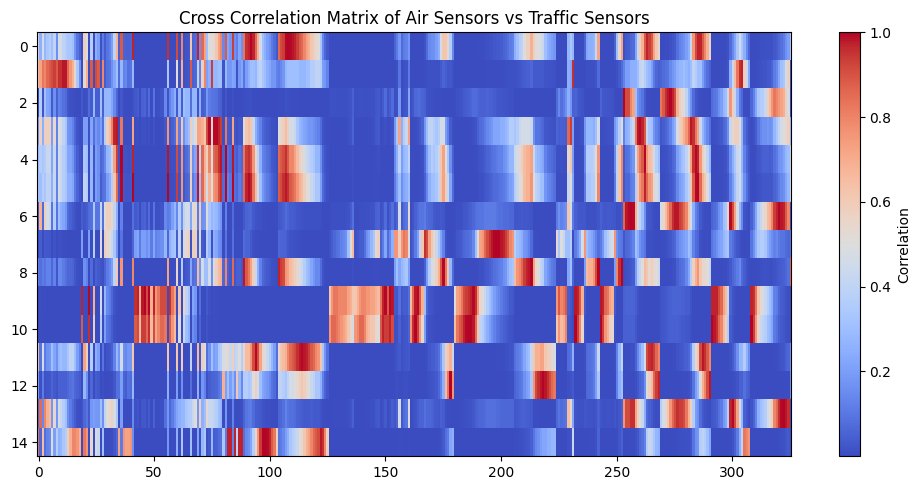

In [7]:
import matplotlib.pyplot as plt

# Plot correlation matrix as heatmap
plt.figure(figsize=(10, 5))
plt.imshow(crs_adj, cmap='coolwarm', interpolation='nearest', aspect='auto')
plt.colorbar(label="Correlation")

# Add ticks and labels
# plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
# plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Cross Correlation Matrix of Air Sensors vs Traffic Sensors")
plt.tight_layout()
plt.show()

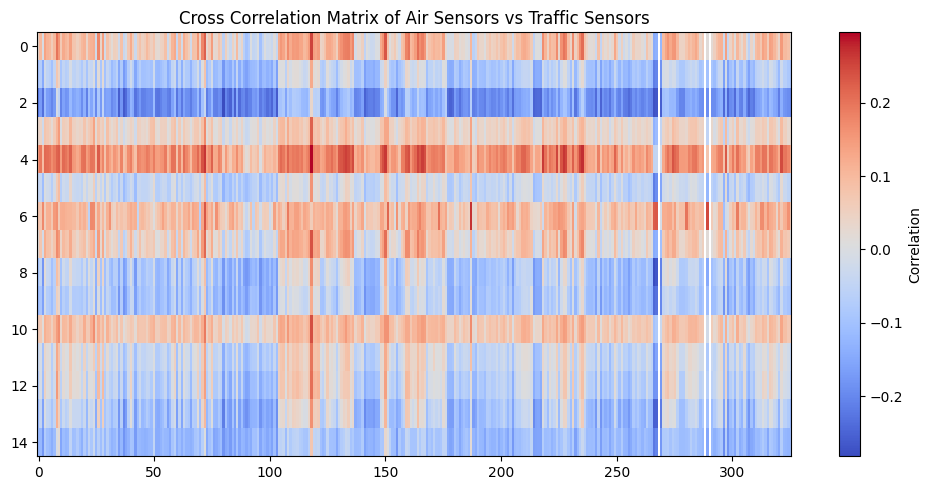

In [8]:
import matplotlib.pyplot as plt

# Plot correlation matrix as heatmap
plt.figure(figsize=(10, 5))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest', aspect='auto')
plt.colorbar(label="Correlation")

# Add ticks and labels
# plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
# plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Cross Correlation Matrix of Air Sensors vs Traffic Sensors")
plt.tight_layout()
plt.show()

In [16]:
(corr_matrix > 0.0).sum(axis=1)

array([267,  34,   1, 284, 319,  62, 306, 255,  54,  24, 311, 128, 109,
        55,   6])

In [14]:
corr_matrix = traffic_data.corr()

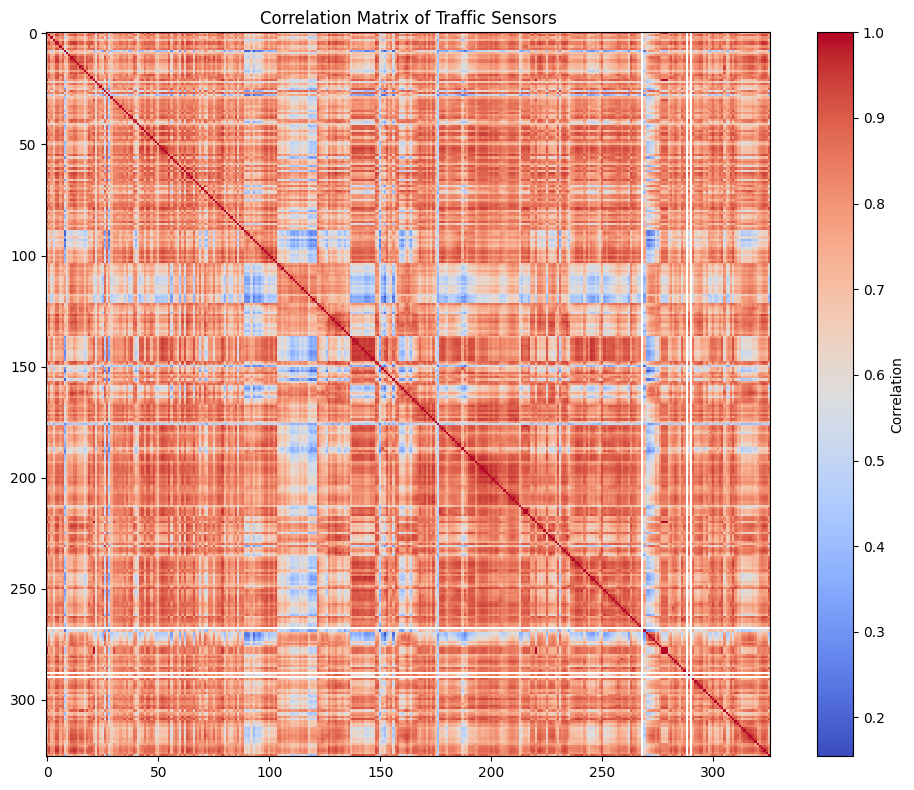

In [15]:
import matplotlib.pyplot as plt

# Plot correlation matrix as heatmap
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label="Correlation")

# Add ticks and labels
# plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
# plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Matrix of Traffic Sensors")
plt.tight_layout()
plt.show()

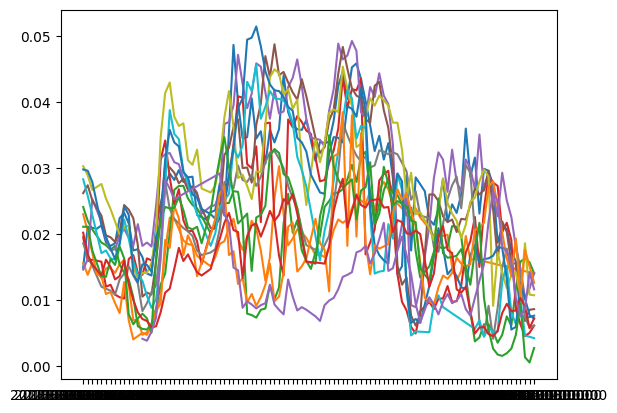

In [8]:
import matplotlib.pyplot as plt

for i in range(15):
    plt.plot(air_data.iloc[:100, i])
# plt.plot(air_data.iloc[:500, 5])
plt.show()

In [4]:
traffic_meta

,id,lat,lng,district,county,fwy_id,n_lanes,direction
0,404356,38.015867,-122.182664,4,Contra Costa,SR4-E,2,E
1,400437,37.813185,-121.993418,4,Contra Costa,I680-S,4,S
2,402835,37.990360,-122.131008,4,Contra Costa,SR4-E,2,E
3,401999,37.832159,-122.004898,4,Contra Costa,I680-S,4,S
4,401925,37.853324,-122.029154,4,Contra Costa,I680-S,4,S
...,...,...,...,...,...,...,...,...
321,401580,37.716980,-121.935122,4,Alameda,I680-S,6,S
322,401356,37.729031,-121.944636,4,Contra Costa,I680-S,4,S
323,401347,37.761220,-121.966344,4,Contra Costa,I680-S,4,S
324,400958,37.784162,-121.979035,4,Contra Costa,I680-S,5,S


In [21]:
full_data.iloc[:, :len(air_meta)]

,Berkeley-Aquatic Park,Concord-2956-A Treat Blvd,Livermore-793 Rincon Avenue,Oakland-9925 International Blvd,Oakland-Laney College,Oakland-West,Pleasanton-Owens Ct,Redwood City,San Francisco-Arkansas Street,San Jose-Jackson Street,San Jose-Knox Avenue,San Pablo-Rumrill Blvd,San Rafael,San Ramon-9885 Alcosta Bl,Vallejo-304 Tuolumne Street
Time,,,,,,,,,,,,,,,
2018-01-01 00:00:00,0.01490,0.01560,0.0241,0.01950,0.0146,0.02620,NaN,0.0186,0.03030,0.0283,0.02980,0.02300,0.02110,0.02020,NaN
2018-01-01 01:00:00,0.02110,0.01380,0.0220,0.01590,0.0162,0.02740,NaN,0.0165,0.02890,0.0258,0.02960,0.02040,0.02110,0.01690,NaN
2018-01-01 02:00:00,0.02095,0.01560,0.0207,0.01610,0.0253,0.02510,NaN,0.0152,0.02670,0.0229,0.02790,0.01715,0.01750,0.01540,NaN
2018-01-01 03:00:00,0.02080,0.01445,0.0197,0.01595,0.0236,0.02395,NaN,0.0136,0.02715,0.0200,0.02465,0.01390,0.01555,0.01455,NaN
2018-01-01 04:00:00,0.02130,0.01330,0.0187,0.01580,0.0219,0.02280,NaN,0.0120,0.02760,0.0171,0.02140,0.01360,0.01360,0.01370,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-31 19:00:00,0.01320,0.00160,0.0011,0.00270,0.0041,0.00840,0.0055,0.0037,0.00630,0.0016,0.00870,0.01190,0.00340,0.00090,0.0018
2018-12-31 20:00:00,0.01470,0.00200,0.0011,0.00230,0.0074,0.00810,0.0035,0.0026,0.00710,0.0014,0.00810,0.00390,0.00330,0.00060,0.0030
2018-12-31 21:00:00,0.01170,0.00200,0.0015,0.00300,0.0042,0.00690,0.0029,0.0028,0.00860,0.0012,0.00710,0.00330,0.00510,0.00070,0.0020


In [19]:
traffic_meta[traffic_meta['id'] == 403349].index.item()

319

In [23]:
traf_num = 401734

indss = traffic_meta[traffic_meta['id'] == traf_num].index.item()
crs_adj[2, indss]

0.07406851638654659

In [12]:
# import pandas as pd
# import numpy as np
# from tsl.ops.similarities import gaussian_kernel

# # Extract unique nodes from each set
# A_nodes = cross_dist['ar_id'].unique()
# B_nodes = cross_dist['tr_id'].unique()

# # Create index maps for fast lookup
# A_index = {node: i for i, node in enumerate(A_nodes)}
# B_index = {node: j for j, node in enumerate(B_nodes)}

# # Initialize adjacency matrix (|A| x |B|)
# adj_matrix = np.zeros((len(A_nodes), len(B_nodes)), dtype=int)

# # Fill adjacency matrix
# for _, row in cross_dist.iterrows():
#     i = A_index[row["ar_id"]]
#     j = B_index[row["tr_id"]]
#     adj_matrix[i, j] = row["dist"]   # 1 = edge exists

# # use same theta for both air and air36
# theta = np.std(adj_matrix)
# adj_matrix = gaussian_kernel(adj_matrix, theta=theta)

# print("Adjacency matrix shape:", adj_matrix.shape)
# print(adj_matrix)


Adjacency matrix shape: (15, 326)
[[0.50341571 0.25007698 0.46743901 ... 0.1608845  0.20211415 0.36577267]
 [0.61464446 0.72520166 0.82685858 ... 0.46743901 0.5772664  0.01789967]
 [0.00862543 0.36577267 0.02128054 ... 0.5772664  0.46743901 0.00106543]
 ...
 [0.20211415 0.01041176 0.11104656 ... 0.0047934  0.00711847 0.18066796]
 [0.07406852 0.85727331 0.14272363 ... 0.98303462 0.95358148 0.01499878]
 [0.82685858 0.06422544 0.651959   ... 0.02520396 0.03495321 0.01252033]]


In [8]:
import folium
from folium.plugins import MousePosition, Search, PolyLineTextPath
import pandas as pd

# Center map at the average location
m = folium.Map(location=[traffic_meta["lat"].mean(), traffic_meta["lng"].mean()], zoom_start=14)

fg = folium.FeatureGroup(name="Markers").add_to(m)

# Add live lat/lon indicator
formatter = "function(num) {return L.Util.formatNum(num, 5);};"

MousePosition(
    position="bottomright",
    separator=" , ",
    empty_string="",
    lng_first=True,
    num_digits=5,
    prefix="Coordinates:",
    lat_formatter=formatter,
    lng_formatter=formatter,
).add_to(m)

# Add points
for _, row in air_meta.iterrows():
    folium.Marker(
        location=[row["latitude"], row["longitude"]],
        popup=row["name"]
    ).add_to(m)

# Add points
for _, row in traffic_meta.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=2,  # Size of the dot in pixels
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.7,
        popup=row["id"],
        tooltip=row["id"]
    ).add_to(fg)

for i, row in enumerate(traffic_adj):
    for j, el in enumerate(row):
        if el > 0 and i != j:
            st = traffic_meta.iloc[i]
            ed = traffic_meta.iloc[j]

            start = [st["lat"].item(), st["lng"].item()]
            end = [ed["lat"].item(), ed["lng"].item()]
        
            # Create polyline for each pair
            line = folium.PolyLine([start, end], color="blue", weight=3, opacity=0.7).add_to(m)
            
            # Add arrow to polyline
            PolyLineTextPath(
                line,
                "▶",  # arrow symbol
                repeat=False,   # one arrow per segment
                offset=6,
                attributes={"fill": "blue", "font-size": "16"}
            ).add_to(m)

for i, row in enumerate(air_adj):
    for j, el in enumerate(row):
        if el > 0 and i != j:
            st = air_meta.iloc[i]
            ed = air_meta.iloc[j]

            start = [st["latitude"].item(), st["longitude"].item()]
            end = [ed["latitude"].item(), ed["longitude"].item()]
        
            # Create polyline for each pair
            line = folium.PolyLine([start, end], color="black", weight=3, opacity=0.7).add_to(m)
            
            # Add arrow to polyline
            PolyLineTextPath(
                line,
                "▶",  # arrow symbol
                repeat=False,   # one arrow per segment
                offset=6,
                attributes={"fill": "black", "font-size": "16"}
            ).add_to(m)

Search(
    layer=fg,
    search_label="popup",   # search by popup text
    placeholder="Search for a location",
    collapsed=False
).add_to(m)


# Save to html
m.save("../data/air_and_traffic_final.html")

In [7]:
import os
import sys
sys.path.insert(0, os.getcwd())

import torch
import random
from omegaconf import DictConfig
from pytorch_lightning import Trainer

import numpy as np

from tsl import logger
from tsl.data import ImputationDataset, SpatioTemporalDataModule
from tsl.data.preprocessing import StandardScaler
from tsl.engines import Imputer
from tsl.metrics import numpy as numpy_metrics
from tsl.transforms import MaskInput
from tsl.utils.casting import torch_to_numpy

from omegaconf import OmegaConf
from geode_filler import GeodeFiller
from geode import Geode

import matplotlib.pyplot as plt
from run_exp import get_dataset
from utils import add_missing_sensors, LargeST

In [8]:
mask_s = None

# mask_s = [1, 8, 9, 21, 35]
# mask_s = [0, 5, 18, 19, 31]
dataset = ['aqi', 'aqism', 'metrla', 'pem07', 'pem04', 'nrel-al', 'nrel-md', 'sd', 'electricity']
np.random.seed(15900376)

# dataset, masked_sensors = get_dataset('air_invercargill2', p_noise=0.25, masked_s=mask_s, mode = 'road', connectivity={'method': 'distance', 'threshold': 0.1, 'include_self': False})
dataset, masked_sensors = get_dataset('aqi', 
                                      p_noise=0.25, 
                                      masked_s=mask_s,
                                      connectivity={'method': 'distance', 'threshold': 0.01, 'include_self': False})#, spatial_shift=True, node_features='c_centrality')
# covariates = {'u': dataset.datetime_encoded('day').values}
adj = dataset.get_connectivity(method='distance', threshold=0.01, include_self=False, layout='dense')

import networkx as nx
from utils import closest_distances_unweighted
import math

unmask = [i for i in range(adj.shape[0]) if i not in masked_sensors]
print(masked_sensors)
masked = list(range(adj.shape[0]))

numpy_graph = nx.from_numpy_array(adj)
closeness = nx.closeness_centrality(numpy_graph)
init_hops = closest_distances_unweighted(numpy_graph, masked, unmask)
print(max(x for x in init_hops.values() if not math.isinf(x)))

[1, 6, 12, 13, 19, 21, 29, 36, 37, 39, 49, 52, 53, 54, 55, 56, 58, 59, 62, 72, 74, 75, 77, 83, 84, 89, 95, 96, 100, 103, 105, 108, 109, 117, 119, 120, 122, 126, 133, 138, 139, 145, 149, 150, 153, 160, 161, 163, 165, 169, 170, 171, 196, 204, 206, 214, 220, 221, 226, 238, 239, 244, 247, 251, 252, 257, 261, 262, 263, 266, 269, 270, 278, 282, 285, 291, 297, 300, 301, 302, 306, 308, 309, 311, 316, 320, 324, 326, 327, 328, 332, 337, 344, 346, 349, 350, 362, 363, 365, 366, 381, 385, 387, 391, 398, 399, 407, 417, 418, 422, 427, 428, 436]
1


In [12]:
torch_dataset = ImputationDataset(target=dataset.dataframe(),
                                      mask=dataset.training_mask,
                                      eval_mask=dataset.eval_mask,
                                      transform=MaskInput(),
                                      connectivity=adj,
                                      window=24,
                                      stride=1)

scalers = {'target': StandardScaler(axis=(0, 1))}
val_len = 0.1
test_len = 0.2
dm = SpatioTemporalDataModule(
    dataset=torch_dataset,
    scalers=scalers,
    splitter=dataset.get_splitter(val_len=val_len, test_len=test_len),
    batch_size=8,
    workers=0)

In [21]:
dm.setup(stage='fit')

In [26]:
next(iter(dm.train_dataloader())).x

tensor([[[[-1.2624e-01],
          [-0.0000e+00],
          [-4.2860e-01],
          ...,
          [-0.0000e+00],
          [ 0.0000e+00],
          [ 0.0000e+00]],

         [[ 5.2435e-02],
          [-0.0000e+00],
          [-5.6604e-01],
          ...,
          [-0.0000e+00],
          [ 0.0000e+00],
          [ 0.0000e+00]],

         [[-1.6747e-01],
          [-0.0000e+00],
          [-5.9353e-01],
          ...,
          [-0.0000e+00],
          [ 0.0000e+00],
          [ 0.0000e+00]],

         ...,

         [[-8.1343e-01],
          [-0.0000e+00],
          [-7.0348e-01],
          ...,
          [-0.0000e+00],
          [-0.0000e+00],
          [-0.0000e+00]],

         [[-7.8594e-01],
          [-0.0000e+00],
          [-7.0348e-01],
          ...,
          [-0.0000e+00],
          [-0.0000e+00],
          [-0.0000e+00]],

         [[-7.7219e-01],
          [-0.0000e+00],
          [-6.4850e-01],
          ...,
          [-0.0000e+00],
          [ 0.0000e+00],
          

In [6]:
import os
from typing import Dict, Literal, Optional, Sequence, Union
import pandas as pd

from tsl.utils import download_url, extract_zip
from tsl.datasets.prototypes import DatetimeDataset
from tsl.datasets.prototypes.casting import to_pandas_freq
from tsl.data.datamodule.splitters import Splitter, disjoint_months
from tsl.data.synch_mode import HORIZON

import numpy as np 
import pandas as pd

class TrafAirSplitter(Splitter):
    def __init__(self,
                 val_len: int = None,
                 test_months: Sequence = (3, 6, 9, 12)):
        super(TrafAirSplitter, self).__init__()
        self._val_len = val_len
        self.test_months = test_months

    def fit(self, dataset):
        nontest_idxs, test_idxs = disjoint_months(dataset,
                                                  months=self.test_months,
                                                  synch_mode=HORIZON)
        # take equal number of samples before each month of testing
        val_len = self._val_len
        if val_len < 1:
            val_len = int(val_len * len(nontest_idxs))
        val_len = val_len // len(self.test_months)
        # get indices of first day of each testing month
        delta = np.diff(test_idxs)
        delta_idxs = np.flatnonzero(delta > delta.min())
        end_month_idxs = test_idxs[1:][delta_idxs]
        if len(end_month_idxs) < len(self.test_months):
            end_month_idxs = np.insert(end_month_idxs, 0, test_idxs[0])
        # expand month indices
        month_val_idxs = [
            np.arange(v_idx - val_len, v_idx) - dataset.window
            for v_idx in end_month_idxs
        ]
        val_idxs = np.concatenate(month_val_idxs) % len(dataset)
        # remove overlapping indices from training set
        ovl_idxs, _ = dataset.overlapping_indices(nontest_idxs,
                                                  val_idxs,
                                                  synch_mode=HORIZON,
                                                  as_mask=True)
        train_idxs = nontest_idxs[~ovl_idxs]
        self.set_indices(train_idxs, val_idxs, test_idxs)

class AirCross(DatetimeDataset):
    similarity_options = {"precomputed"}

    def __init__(self,
                 root: str = None,
                 test_months: Sequence = (3, 6, 9, 12),
                 imputation_mode: Literal["nearest", "zero", None] = "zero",
                 freq: str = "h",
                 include_traffic: bool = False):
        # set root path
        self.root = root
        self.imputation_mode = imputation_mode
        self.test_months = test_months
        self.include_traffic = include_traffic

        assert imputation_mode in ["nearest", "zero", None]

        # Set dataset frequency here to resample when loading
        if freq is not None:
            freq = to_pandas_freq(freq)
        self.freq = freq

        # load dataset
        readings, mask, adj, air_metadata, tra_metadata = self.load()
        self.tra_metadata = tra_metadata
        self.air_metadata = air_metadata
        covariates = {"adj": (adj, 'n n')}
        
        super().__init__(target=readings,
                         freq=freq,
                         mask=mask,
                         covariates=covariates,
                         similarity_score="precomputed",
                         temporal_aggregation="mean",
                         spatial_aggregation="mean")

    def load_raw(self):
        # load sensors information
        air_metadata = pd.read_csv(os.path.join(self.root_dir, 'air_metadata.csv'))
        self.air_max_nodes = len(air_metadata)

        tra_metadata = pd.read_csv(os.path.join(self.root_dir, 'traffic_metadata.csv'))
        self.tra_max_nodes = len(tra_metadata)

        readings = pd.read_csv(os.path.join(self.root_dir, 'full_data.csv'), index_col=0, parse_dates=['Time'])
        if not self.include_traffic:
            readings = readings.iloc[:, :len(air_metadata)]

        # resample here to aggregate only valid observations and
        # align to authors' preprocessing
        if self.freq is not None:
            readings = readings.apply(pd.to_numeric, errors='coerce')
            readings = readings.resample(self.freq).mean()

        # load adjacency
        ar_edge_index, ar_edge_weight = np.load(os.path.join(self.root_dir, 'air_adj.npz')).values()
        ar_adj = np.eye(self.air_max_nodes, dtype=np.float32)
        ar_adj[tuple(ar_edge_index)] = ar_edge_weight

        # Get adj for traffic 
        if self.include_traffic:
            tr_edge_index, tr_edge_weight = np.load(os.path.join(self.root_dir, 'traffic_adj.npz')).values()
            cr_edge_index, cr_edge_weight = np.load(os.path.join(self.root_dir, 'cross_adj.npz')).values()
            # build square adj from coo to add adj as covariate

            tr_adj = np.eye(self.tra_max_nodes, dtype=np.float32)
            tr_adj[tuple(tr_edge_index)] = tr_edge_weight

            cr_adj = np.zeros((self.air_max_nodes, self.tra_max_nodes), dtype=np.float32)
            cr_adj[tuple(cr_edge_index)] = cr_edge_weight

            # cross_adj = pd.read_csv(os.path.join(self.root_dir, 'cross_dist.csv'))
            adj = np.block([
                [ar_adj,  cr_adj],
                [cr_adj.T, tr_adj]
            ])
        else:
            adj = ar_adj

        return readings, adj, air_metadata, tra_metadata
    
    def get_splitter(self, method: Optional[str] = None, **kwargs):
        if method == 'air_quality':
            val_len = kwargs.get('val_len')
            return TrafAirSplitter(test_months=self.test_months,
                                    val_len=val_len)

    def load(self):
        readings, adj, air_metadata, tra_metadata = self.load_raw()
        # impute missing observations using last observed values
        # in authors' code: readings = readings.fillna(0)
        mask = ~readings.isna().values
        if self.imputation_mode == "nearest":
            readings = readings.ffill().bfill()
        elif self.imputation_mode == "zero":
            readings = readings.fillna(0)
        return readings, mask, adj, air_metadata, tra_metadata

    def compute_similarity(self, method: str, **kwargs):
        if method == "precomputed":
            # load precomputed adjacency matrix based on road distance
            return self.adj

In [7]:
AirCross(root='../data')

AirCross(length=8760, n_nodes=15, n_channels=1)

In [8]:
from tsl.ops.imputation import to_missing_values_dataset
from utils import shift_mask, sample_mask

def add_missing_sensors_cross(dataset: AirCross,
                              p_noise=0.05,
                              p_fault=0.01,
                              min_seq=1,
                              max_seq=10,
                              seed=None,
                              inplace=True,
                              masked_sensors = [],
                              connect = None,
                              spatial_shift = False, 
                              order = 0,
                              node_features = 'CC',
                              mode='road'):
    if seed is None:
        seed = np.random.randint(1e9)
    # Fix seed for random mask generation
    random = np.random.default_rng(seed)

    # Compute evaluation mask
    shape = (dataset.length, dataset.air_max_nodes, dataset.n_channels)
    adj = dataset.get_connectivity(**connect, layout='dense')
    air_adj = adj[:dataset.air_max_nodes, :dataset.air_max_nodes]  
    eval_mask = dataset.mask

    if masked_sensors is None:
        if spatial_shift:
            tmp_mask = shift_mask(shape, feature=node_features, order=order, 
                                   adj=air_adj)
            dataset.seed = seed
        else:
            tmp_mask = sample_mask(shape,
                                    p=p_fault,
                                    p_noise=p_noise,
                                    mode=mode,
                                    adj=air_adj)
            
            dataset.p_fault = p_fault
            dataset.p_noise = p_noise
            dataset.min_seq = min_seq
            dataset.max_seq = max_seq
            dataset.seed = seed
            dataset.random = random

        # mask = rearrange(eval_mask, "b n 1 -> b n")
        mask_sum = tmp_mask.sum(0)  # n
        masked_sensors = (np.where(mask_sum > 0)[0]).tolist()
        eval_mask[:, :dataset.air_max_nodes] = tmp_mask
    else:
        masked_sensors = list(masked_sensors)
        eval_mask = np.zeros_like(dataset.mask)
        eval_mask[:, masked_sensors] = dataset.mask[:, masked_sensors]

    # Convert to missing values dataset
    dataset = to_missing_values_dataset(dataset, eval_mask, inplace)

    test2 = np.sum(dataset.mask, axis=(0))
    test1 = np.sum(eval_mask, axis=(0))

    # Store evaluation mask params in dataset
    return dataset, masked_sensors

In [16]:
dataset, missingsensors = add_missing_sensors_cross(AirCross(root='../data', include_traffic=True),
                                p_fault=0.,
                                p_noise=0.25,
                                min_seq=12,
                                max_seq=12 * 4,
                                masked_sensors=None,
                                connect={'method': 'precomputed',
                                        'threshold': 0.1,
                                        'include_self': False},
                                spatial_shift=True,
                                order=0,
                                node_features='CC')

In [17]:
dataset.adj.shape

(341, 341)

In [5]:
trafadj = dataset.adj[15:, 15:]

In [6]:
np.where((trafadj.sum(axis=1) + trafadj.sum(axis=0)) == 0)

(array([], dtype=int64),)

In [7]:
data = pd.read_csv('/home/mala711/miniconda3/envs/geode/lib/python3.10/site-packages/tsl/.storage/LargeST/sensors/metadata.csv')
values = pd.read_hdf('/home/mala711/miniconda3/envs/geode/lib/python3.10/site-packages/tsl/.storage/LargeST/2018/data.h5')
values = values['2018-01-01 00:00:00': '2018-12-31 23:59:59']
values = values.loc[values.index.minute.isin([0])]
node_mask = (data.district == 4).values
fin_df = values.loc[:, node_mask]
fin_df

,404356,402518,402516,402214,402212,402210,402835,414294,414295,402513,...,401144,401615,401413,401896,400642,401273,401137,401610,401416,401911
Time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,26.0,47.0,36.0,36.0,36.0,35.0,0.0,13.0,24.0,26.0,...,31.0,0.0,84.0,41.0,5.0,67.0,92.0,40.0,79.0,31.0
2018-01-01 01:00:00,36.0,78.0,21.0,21.0,21.0,35.0,0.0,57.0,63.0,67.0,...,60.0,103.0,192.0,99.0,78.0,101.0,143.0,86.0,122.0,51.0
2018-01-01 02:00:00,28.0,71.0,14.0,14.0,14.0,35.0,0.0,32.0,39.0,39.0,...,31.0,79.0,193.0,86.0,46.0,98.0,114.0,61.0,102.0,44.0
2018-01-01 03:00:00,17.0,54.0,12.0,12.0,12.0,35.0,0.0,26.0,31.0,36.0,...,42.0,0.0,104.0,56.0,5.0,88.0,157.0,53.0,85.0,29.0
2018-01-01 04:00:00,14.0,47.0,13.0,13.0,13.0,35.0,0.0,13.0,18.0,19.0,...,29.0,0.0,85.0,46.0,5.0,62.0,108.0,41.0,72.0,31.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-31 19:00:00,151.0,104.0,206.0,206.0,206.0,206.0,70.0,85.0,115.0,139.0,...,114.0,195.0,318.0,147.0,152.0,156.0,250.0,177.0,220.0,127.0
2018-12-31 20:00:00,110.0,75.0,163.0,163.0,163.0,163.0,35.0,55.0,74.0,106.0,...,80.0,153.0,245.0,94.0,113.0,141.0,236.0,139.0,183.0,98.0
2018-12-31 21:00:00,91.0,66.0,137.0,137.0,137.0,137.0,37.0,47.0,73.0,107.0,...,73.0,134.0,253.0,93.0,96.0,123.0,186.0,103.0,158.0,79.0


In [15]:
traffic_meta.iloc[[  8,  214, 176, 241, 250, 305]]

,id,lat,lng,district,county,fwy_id,n_lanes,direction
8,401476,38.013608,-121.998840,4,Contra Costa,SR4-W,4,W
214,402559,37.857163,-122.497555,4,Marin,US101-N,4,N
176,409306,37.833093,-122.481888,4,Marin,US101-N,3,N
241,404647,37.711347,-122.455028,4,San Francisco,I280-S,4,S
250,403910,37.675831,-122.470236,4,San Mateo,I280-S,4,S
305,400265,38.070185,-122.126360,4,Solano,I680-S,2,S


In [63]:
ids = [401476, 402559, 404647, 403910, 400265, 403902]
data[data['id'].isin(ids)]

,id,lat,lng,district,county,fwy_id,n_lanes,direction
596,401476,38.013608,-121.998840,4,Contra Costa,SR4-W,4,W
1486,402559,37.857163,-122.497555,4,Marin,US101-N,4,N
2131,403910,37.675831,-122.470236,4,San Mateo,I280-S,4,S
2133,403902,37.702855,-122.472093,4,San Mateo,I280-S,3,S
2134,404647,37.711347,-122.455028,4,San Francisco,I280-S,4,S
2598,400265,38.070185,-122.126360,4,Solano,I680-S,2,S


In [33]:
fin_df[404647].astype(float)

Time
2018-01-01 00:00:00     75.0
2018-01-01 01:00:00    202.0
2018-01-01 02:00:00    172.0
2018-01-01 03:00:00    150.0
2018-01-01 04:00:00     79.0
                       ...  
2018-12-31 19:00:00    152.0
2018-12-31 20:00:00    226.0
2018-12-31 21:00:00    186.0
2018-12-31 22:00:00    183.0
2018-12-31 23:00:00    134.0
Name: 404647, Length: 8760, dtype: float64

In [52]:
np.array(fin_df[404647])[2413]

nan

In [ ]:
traffic_meta.iloc[8] = data.iloc[596]
traffic_meta.iloc[241] = data.iloc[2134]
traffic_meta.iloc[250] = data.iloc[2131]
traffic_meta.iloc[305] = data.iloc[2598]
traffic_meta.iloc[214] = data.iloc[1486]

In [69]:
traffic_data.columns

Index(['404356', '400437', '402835', '401999', '401925', '400053', '405046',
       '401519', '401476', '402072',
       ...
       '403337', '403343', '403346', '403349', '401596', '401580', '401356',
       '401347', '400958', '403902'],
      dtype='object', length=326)

In [67]:
traffic_meta

,id,lat,lng,district,county,fwy_id,n_lanes,direction
0,404356,38.015867,-122.182664,4,Contra Costa,SR4-E,2,E
1,400437,37.813185,-121.993418,4,Contra Costa,I680-S,4,S
2,402835,37.990360,-122.131008,4,Contra Costa,SR4-E,2,E
3,401999,37.832159,-122.004898,4,Contra Costa,I680-S,4,S
4,401925,37.853324,-122.029154,4,Contra Costa,I680-S,4,S
...,...,...,...,...,...,...,...,...
321,401580,37.716980,-121.935122,4,Alameda,I680-S,6,S
322,401356,37.729031,-121.944636,4,Contra Costa,I680-S,4,S
323,401347,37.761220,-121.966344,4,Contra Costa,I680-S,4,S
324,400958,37.784162,-121.979035,4,Contra Costa,I680-S,5,S


In [73]:
traffic_meta.iloc[[  8,  28, 176, 241, 250, 305, 325]]

,id,lat,lng,district,county,fwy_id,n_lanes,direction
8,401476,38.013608,-121.998840,4,Contra Costa,SR4-W,4,W
28,405275,38.022488,-121.962645,4,Contra Costa,SR4-W,4,W
176,409306,37.833093,-122.481888,4,Marin,US101-N,3,N
241,404647,37.711347,-122.455028,4,San Francisco,I280-S,4,S
250,403910,37.675831,-122.470236,4,San Mateo,I280-S,4,S
305,400265,38.070185,-122.126360,4,Solano,I680-S,2,S
325,403902,37.702855,-122.472093,4,San Mateo,I280-S,3,S


In [109]:
traffic_data = traffic_data.rename(columns={'401568': '401476',
                                            '402560':'402559',
                                            '404617':'404647',
                                            '401512':'403910',
                                            '400295':'400265',})

In [114]:
traffic_meta['id']

0      404356
1      400437
2      402835
3      401999
4      401925
        ...  
321    401580
322    401356
323    401347
324    400958
325    403902
Name: id, Length: 326, dtype: int64

In [12]:
adj_file = np.load('/home/mala711/miniconda3/envs/geode/lib/python3.10/site-packages/tsl/.storage/LargeST/sensors/adj.npz')
edge_index = adj_file['edge_index']
edge_weight = adj_file['edge_weight']

adj = np.eye(len(data), dtype=np.float32)
adj[tuple(edge_index)] = edge_weight
adj = adj[node_mask][:, node_mask]

In [13]:
node_mask.shape

(8600,)

In [14]:
adj.shape

(2352, 2352)

In [21]:
new_data = data[data.district == 4]

In [24]:
new_data = new_data.reset_index()

In [37]:
inds = []

for ind, row in traffic_meta.iterrows():
    inds.append(new_data[new_data['id'] == row['id']].index.values.astype(int)[0])

In [40]:
adj = adj[inds][:, inds]

In [41]:
edge_weight = []
edge_index = []

for i, row in enumerate(adj):
    for j, el in enumerate(row):
        if el > 0:
            edge_weight.append(el)
            edge_index.append([i, j])

In [42]:
edge_weight = np.array(edge_weight)
edge_index = np.array(edge_index).T

In [43]:
np.savez('/home/mala711/GEODE2025/data/traffic_adj.npz', edge_weight=edge_weight, edge_index=edge_index)